In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Exploratory Data Analysis (EDA)
We will look at the dataset structure, statistics, and check for missing values.

In [2]:
df = pd.read_csv('Food_Delivery_Times.csv')
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [3]:
#1. looking Shape
#2. Top 5 and bottom 5 rows
#3. Data types
#4. Info
#5. Total Null Values
#6. Visaulizing Target Column (Delivery_Time_min)

In [4]:
df.shape

(1000, 9)

In [5]:
df.tail()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55
999,103,6.63,Foggy,Low,Night,Scooter,24,3.0,58


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [7]:
df.dtypes

,0
Order_ID,int64
Distance_km,float64
Weather,object
Traffic_Level,object
Time_of_Day,object
Vehicle_Type,object
Preparation_Time_min,int64
Courier_Experience_yrs,float64
Delivery_Time_min,int64


In [8]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


<Axes: xlabel='Delivery_Time_min', ylabel='Count'>

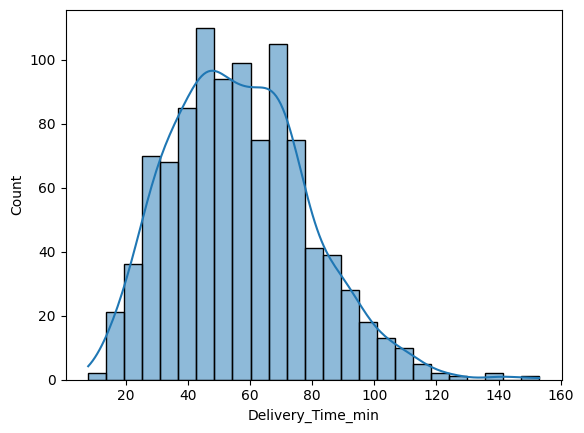

In [9]:
sns.histplot(df['Delivery_Time_min'], kde=True)

In [10]:
print((df.isnull().sum()))
print(df.dtypes)

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64
Order_ID                    int64
Distance_km               float64
Weather                    object
Traffic_Level              object
Time_of_Day                object
Vehicle_Type               object
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object


In [11]:
cat_cols = ['Weather', 'Traffic_Level', 'Time_of_Day']
df[cat_cols]=df[cat_cols].fillna(df[cat_cols].mode)



df['Courier_Experience_yrs']=df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].mean())

print(df.isnull().sum())

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


### 2. Feature Engineering & Preprocessing
We will encode categorical variables manually using One-Hot Encoding and drop unnecessary columns like `Order_ID`.

In [12]:
cat_cols=['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
df=pd.get_dummies(df, columns=cat_cols)



In [13]:
df.columns

Index(['Order_ID', 'Distance_km', 'Preparation_Time_min',
       'Courier_Experience_yrs', 'Delivery_Time_min',
       'Weather_<bound method DataFrame.mode of     Weather Traffic_Level Time_of_Day\n0     Windy           Low   Afternoon\n1     Clear        Medium     Evening\n2     Foggy           Low       Night\n3     Rainy        Medium   Afternoon\n4     Clear           Low     Morning\n..      ...           ...         ...\n995   Clear          High     Evening\n996   Rainy           Low     Morning\n997   Snowy          High     Evening\n998   Clear           Low   Afternoon\n999   Foggy           Low       Night\n\n[1000 rows x 3 columns]>',
       'Weather_Clear', 'Weather_Foggy', 'Weather_Rainy', 'Weather_Snowy',
       'Weather_Windy',
       'Traffic_Level_<bound method DataFrame.mode of     Weather Traffic_Level Time_of_Day\n0     Windy           Low   Afternoon\n1     Clear        Medium     Evening\n2     Foggy           Low       Night\n3     Rainy        Medium   Aftern

### 3. Data Splitting
Splitting the data into Features (X) and Target (y), then into Training and Testing sets.

In [14]:
X=df.drop(columns=['Delivery_Time_min','Order_ID'])
y=df['Delivery_Time_min']

### 4. Model Training & Evaluation
We will train a Decision Tree Regressor and a Random Forest Regressor, then compare their performance using Mean Absolute Error and R-squared.

In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [16]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

#Object of decision Tree and random forest

dt_model=DecisionTreeRegressor()
rf_model=RandomForestRegressor(max_depth= 20,min_samples_leaf= 4,min_samples_split= 2,n_estimators= 200)

In [17]:
#we can never rely on one scoring matrics for both regression and classification

In [18]:
dt_model.fit(X_train,y_train)
rf_model.fit(X_train,y_train)

RandomForestRegressor(max_depth=20, min_samples_leaf=4, n_estimators=200)

In [19]:
dt_model.predict(X_test)
rf_model.predict(X_test)

array([ 35.34674153,  66.67826099,  42.45830977,  48.87863388,
        85.04127195,  36.79000885,  67.38391113,  30.10467334,
        35.88104665,  73.00339175,  73.07755994,  62.6497637 ,
        39.98474887,  76.73493233,  88.15387928,  82.20799979,
        31.65371064,  70.69403018,  48.41798994,  61.81819641,
        82.86154867,  29.36241579,  70.90881935,  77.18900367,
        58.65639419,  35.46713328,  81.67834173,  26.80713443,
        50.88759432,  62.18367136,  67.1513276 ,  20.22918509,
        58.66700805,  39.68959045,  72.55677092,  19.10418468,
        68.90990703,  55.80966454,  50.74820697,  74.60494394,
        73.80597514,  32.50296669,  71.28716438,  69.78887091,
        41.73274326,  19.04001263,  91.63803204,  78.92887775,
        80.52280712,  31.17496465,  60.70252624,  63.4458474 ,
        40.16278079,  77.90334628,  53.27844129,  53.18259944,
        76.02887845,  78.72470838,  61.82021445,  83.86865422,
        52.85838593,  37.08570196,  49.51512131,  49.66

In [20]:
#checking r2score for both decision tree and random foreston training and testing

#Decision tree
from sklearn.metrics import r2_score,mean_absolute_error
print(f" R2 score for dt Training data {r2_score(y_train,dt_model.predict(X_train))}")
print(f" MAE for dt Training data {mean_absolute_error(y_train,dt_model.predict(X_train))}")

print(f" R2 score for dt testing data {r2_score(y_test,dt_model.predict(X_test))}")
print(f" MAE for dt testing data {mean_absolute_error(y_test,dt_model.predict(X_test))}")

#random forest
print(r2_score(y_train,rf_model.predict(X_train)))
print(mean_absolute_error(y_train,rf_model.predict(X_train)))


print(r2_score(y_test,rf_model.predict(X_test)))
print(mean_absolute_error(y_test,rf_model.predict(X_test)))



 R2 score for dt Training data 1.0
 MAE for dt Training data 0.0
 R2 score for dt testing data 0.5906458742071838
 MAE for dt testing data 10.21
0.8503076917061498
5.257053124113894
0.8062271282524887
6.621437882795523


**5. Hyperparameter Tuning**

We will use GridSearchCV to find the best parameters for the Random Forest Regressor to improve its generalization on the test set.

In [21]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

In [22]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(
    estimator = rf_model,
    param_grid = param_grid,
    scoring = 'neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,#Jitne bhi cores free hai they will perform parameter tuning
    verbose = 1#Display the execution
)

In [23]:
#Fit the model on training set
grid_search.fit(X_train,y_train)

Fitting 3 folds for each of 54 candidates, totalling 162 fits


GridSearchCV(cv=3,
             estimator=RandomForestRegressor(max_depth=20, min_samples_leaf=4,
                                             n_estimators=200),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200]},
             scoring='neg_mean_absolute_error', verbose=1)

In [24]:
grid_search.best_params_

{'max_depth': 10,
 'min_samples_leaf': 2,
 'min_samples_split': 10,
 'n_estimators': 200}

In [25]:
best_rf_model = grid_search.best_estimator_

In [26]:
tuned_predictions = best_rf_model.predict(X_test)

In [27]:
r2_score(y_test,tuned_predictions)

0.8105635267734721

In [28]:
mean_absolute_error(y_test,tuned_predictions)

6.573095950859459

In [31]:
import joblib

joblib.dump(best_rf_model, "rf_model__2_.pkl")

['rf_model__2_.pkl']